# Structured Soil Nutrient-Deficiency Modeling

This notebook develops machine-learning models for estimating nitrogen (N),
phosphorus (P), and potassium (K) deficiency from structured soil and
environmental features.

## Objectives

- Load the structured soil dataset
- Examine N, P, and K distributions
- Define project-level proxy deficiency targets
- Prepare feature matrices while preventing direct target leakage
- Split the data into training and test sets
- Train Gradient Boosting baseline models
- Evaluate accuracy, precision, recall, and F1-score
- Tune the Gradient Boosting hyperparameters using cross-validation
- Compare baseline and tuned models
- Select and save the final model for each nutrient

The original dataset contains a crop-recommendation label rather than
laboratory-confirmed nutrient-deficiency labels. Therefore, N, P, and K
deficiency targets in this notebook are explicitly treated as proxy labels.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os

DATA_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Structured_Data/Crop_recommendationV2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2200, 23)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

Data types:
N                           int64
P                           int64
K                           int64
temperature               float64
humidity                  float64
ph                        float64
rainfall                  float64
label                      object
soil_moisture             float64
soil_type                   int64
sunlight_exposure         float64
wind_speed                float64
co2_concentration         float64
organic_matter            float64
irrigation_frequency        int64
crop_density              float64
pest_pressure             float64
fertilizer_usage     

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [ ]:
print("Label values:")
print(df["label"].value_counts())

print("\nNumber of unique labels:", df["label"].nunique())

Label values:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Number of unique labels: 22


In [ ]:
nutrients = ["N", "P", "K"]

print("Nutrient statistics:")
display(df[nutrients].describe())

print("\nNutrient ranges:")
for nutrient in nutrients:
    print(
        f"{nutrient}: "
        f"min={df[nutrient].min()}, "
        f"max={df[nutrient].max()}, "
        f"mean={df[nutrient].mean():.2f}, "
        f"median={df[nutrient].median():.2f}"
    )

Nutrient statistics:


,N,P,K
count,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091
std,36.917334,32.985883,50.647931
min,0.000000,5.000000,5.000000
25%,21.000000,28.000000,20.000000
50%,37.000000,51.000000,32.000000
75%,84.250000,68.000000,49.000000
max,140.000000,145.000000,205.000000



Nutrient ranges:
N: min=0, max=140, mean=50.55, median=37.00
P: min=5, max=145, mean=53.36, median=51.00
K: min=5, max=205, mean=48.15, median=32.00


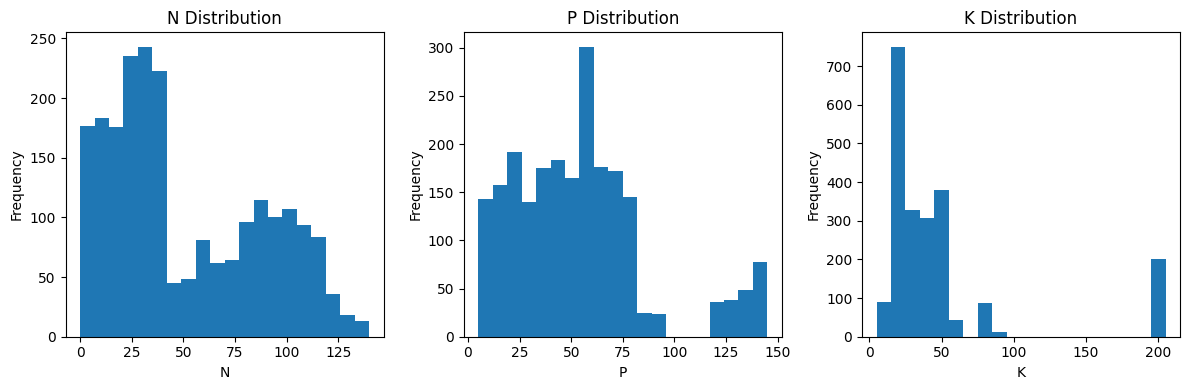

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

for i, nutrient in enumerate(["N", "P", "K"], 1):
    plt.subplot(1, 3, i)
    plt.hist(df[nutrient], bins=20)
    plt.title(f"{nutrient} Distribution")
    plt.xlabel(nutrient)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
nutrient_by_crop = df.groupby("label")[["N", "P", "K"]].agg(
    ["mean", "median", "min", "max"]
)

display(nutrient_by_crop)

N                        P                        K         \
               mean median  min  max    mean median  min  max    mean median   
label                                                                          
apple         20.80   24.0    0   40  134.22  136.5  120  145  199.89  200.0   
banana       100.23  100.5   80  120   82.01   81.0   70   95   50.05   50.0   
blackgram     40.02   41.0   20   60   67.47   67.0   55   80   19.24   19.0   
chickpea      40.09   39.0   20   60   67.79   68.0   55   80   79.92   79.0   
coconut       21.98   24.0    0   40   16.93   15.5    5   30   30.59   31.0   
coffee       101.20  103.0   80  120   28.74   29.0   15   40   29.94   30.0   
cotton       117.77  117.0  100  140   46.24   46.0   35   60   19.56   19.0   
grapes        23.18   24.0    0   40  132.53  133.0  120  145  200.11  201.0   
jute          78.40   78.0   60  100   46.86   46.0   35   60   39.99   40.0   
kidneybeans   20.75   22.0    0   40   67.54   67.0   55   80   20.05   20.0   
lentil        18.77   16.5    0   40   68.36   68.0   55   80   19.41   19.0   
maize         77.76   76.0   60  100   48.44   48.5   35   60   19.79   20.0   
mango         20.07   21.0    0   40   27.18   27.5   15   40   29.92   30.0   
mothbeans     21.44   22.0    0   40   48.01   48.5   35   60   20.23   20.0   
mungbean      20.99   22.0    0   40   47.28   47.0   35   60   19.87   20.0   
muskmelon    100.32  100.0   80  120   17.72   18.0    5   30   50.08   50.0   
orange        19.58   19.0    0   40   16.55   16.0    5   30   10.01   10.0   
papaya        49.88   49.0   31   70   59.05   60.0   46   70   50.04   50.0   
pigeonpeas    20.73   20.0    0   40   67.73   69.5   55   80   20.29   20.0   
pomegranate   18.87   18.0    0   40   18.75   20.0    5   30   40.21   40.0   
rice          79.89   80.0   60   99   47.58   47.0   35   60   39.87   40.0   
watermelon    99.42   99.0   80  120   17.00   17.5    5   30   50.22   50.5   

                       
             min  max  
label                  
apple        195  205  
banana        45   55  
blackgram     15   25  
chickpea      75   85  
coconut       25   35  
coffee        25   35  
cotton        15   25  
grapes       195  205  
jute          35   45  
kidneybeans   15   25  
lentil        15   25  
maize         15   25  
mango         25   35  
mothbeans     15   25  
mungbean      15   25  
muskmelon     45   55  
orange         5   15  
papaya        45   55  
pigeonpeas    15   25  
pomegranate   35   45  
rice          35   45  
watermelon    45   55

In [ ]:
crop_nutrients = df.groupby("label")[["N", "P", "K"]].mean().round(2)

display(crop_nutrients)

,N,P,K
label,,,
apple,20.80,134.22,199.89
banana,100.23,82.01,50.05
blackgram,40.02,67.47,19.24
chickpea,40.09,67.79,79.92
coconut,21.98,16.93,30.59
coffee,101.20,28.74,29.94
cotton,117.77,46.24,19.56
grapes,23.18,132.53,200.11
jute,78.40,46.86,39.99


In [ ]:
N_threshold = df["N"].quantile(0.25)
P_threshold = df["P"].quantile(0.25)
K_threshold = df["K"].quantile(0.25)

print(f"N deficiency threshold: {N_threshold:.2f}")
print(f"P deficiency threshold: {P_threshold:.2f}")
print(f"K deficiency threshold: {K_threshold:.2f}")

N deficiency threshold: 21.00
P deficiency threshold: 28.00
K deficiency threshold: 20.00


In [ ]:
df["N_deficient"] = (df["N"] < N_threshold).astype(int)
df["P_deficient"] = (df["P"] < P_threshold).astype(int)
df["K_deficient"] = (df["K"] < K_threshold).astype(int)

print("N deficiency distribution:")
print(df["N_deficient"].value_counts())

print("\nP deficiency distribution:")
print(df["P_deficient"].value_counts())

print("\nK deficiency distribution:")
print(df["K_deficient"].value_counts())

N deficiency distribution:
N_deficient
0    1664
1     536
Name: count, dtype: int64

P deficiency distribution:
P_deficient
0    1660
1     540
Name: count, dtype: int64

K deficiency distribution:
K_deficient
0    1722
1     478
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split


feature_columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "soil_moisture",
    "soil_type",
    "sunlight_exposure",
    "wind_speed",
    "co2_concentration",
    "organic_matter",
    "irrigation_frequency",
    "crop_density",
    "pest_pressure",
    "fertilizer_usage",
    "growth_stage",
    "urban_area_proximity",
    "water_source_type",
    "frost_risk",
    "water_usage_efficiency"
]

print("Total candidate features:", len(feature_columns))
print(feature_columns)

Total candidate features: 22
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']


## Proxy Nutrient-Deficiency Labels

The original dataset does not contain ground-truth labels indicating whether
a soil sample is deficient in nitrogen, phosphorus, or potassium.

To enable the required nutrient-deficiency classification experiments, this
project derives proxy labels using the 25th percentile of each nutrient's
distribution.

The rule is:

- N < 25th percentile → N deficient
- P < 25th percentile → P deficient
- K < 25th percentile → K deficient

For this dataset, the resulting thresholds are:

- N threshold: 21
- P threshold: 28
- K threshold: 20

A value below the corresponding threshold is assigned class 1
(`Deficient`), while a value at or above the threshold is assigned class 0
(`Not Deficient`).

These are dataset-relative proxy labels and are not equivalent to
laboratory-confirmed agronomic deficiency thresholds.

In [ ]:

X_N = df[[col for col in feature_columns if col != "N"]]
y_N = df["N_deficient"]

X_P = df[[col for col in feature_columns if col != "P"]]
y_P = df["P_deficient"]

X_K = df[[col for col in feature_columns if col != "K"]]
y_K = df["K_deficient"]

print("N model:", X_N.shape, y_N.shape)
print("P model:", X_P.shape, y_P.shape)
print("K model:", X_K.shape, y_K.shape)

N model: (2200, 21) (2200,)
P model: (2200, 21) (2200,)
K model: (2200, 21) (2200,)


In [ ]:
print("N deficiency distribution:")
print(df["N_deficient"].value_counts())

print("\nP deficiency distribution:")
print(df["P_deficient"].value_counts())

print("\nK deficiency distribution:")
print(df["K_deficient"].value_counts())

In [ ]:
X_N_train, X_N_test, y_N_train, y_N_test = train_test_split(
    X_N, y_N,
    test_size=0.20,
    random_state=42,
    stratify=y_N
)

X_P_train, X_P_test, y_P_train, y_P_test = train_test_split(
    X_P, y_P,
    test_size=0.20,
    random_state=42,
    stratify=y_P
)

X_K_train, X_K_test, y_K_train, y_K_test = train_test_split(
    X_K, y_K,
    test_size=0.20,
    random_state=42,
    stratify=y_K
)

print("N model:")
print("Training:", X_N_train.shape)
print("Testing :", X_N_test.shape)

print("\nP model:")
print("Training:", X_P_train.shape)
print("Testing :", X_P_test.shape)

print("\nK model:")
print("Training:", X_K_train.shape)
print("Testing :", X_K_test.shape)

N model:
Training: (1760, 21)
Testing : (440, 21)

P model:
Training: (1760, 21)
Testing : (440, 21)

K model:
Training: (1760, 21)
Testing : (440, 21)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier


gb_N = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_N.fit(X_N_train, y_N_train)

print("N deficiency model trained successfully.")

N deficiency model trained successfully.


In [ ]:
y_N_pred = gb_N.predict(X_N_test)

print("First 20 predictions:")
print(y_N_pred[:20])

print("\nFirst 20 actual values:")
print(y_N_test.values[:20])

First 20 predictions:
[0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0]

First 20 actual values:
[1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0]


## Target Leakage Prevention

Because each proxy deficiency target is derived directly from its
corresponding nutrient value, that nutrient is excluded from the feature
matrix for its own prediction task.

Therefore:

- N is excluded when predicting N deficiency
- P is excluded when predicting P deficiency
- K is excluded when predicting K deficiency

This prevents the model from receiving the direct variable used to construct
the target label.

## Target Leakage Prevention

Because each proxy deficiency target is derived directly from its
corresponding nutrient value, that nutrient is excluded from the feature
matrix for its own prediction task.

Therefore:

- N is excluded when predicting N deficiency
- P is excluded when predicting P deficiency
- K is excluded when predicting K deficiency

This prevents the model from receiving the direct variable used to construct
the target label.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_N = accuracy_score(y_N_test, y_N_pred)
precision_N = precision_score(y_N_test, y_N_pred)
recall_N = recall_score(y_N_test, y_N_pred)
f1_N = f1_score(y_N_test, y_N_pred)

print(f"N Deficiency Model Performance")
print(f"Accuracy : {accuracy_N:.4f}")
print(f"Precision: {precision_N:.4f}")
print(f"Recall   : {recall_N:.4f}")
print(f"F1 Score : {f1_N:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_N_test,
        y_N_pred,
        target_names=["Not Deficient", "Deficient"]
    )
)

N Deficiency Model Performance
Accuracy : 0.7432
Precision: 0.4583
Recall   : 0.3084
F1 Score : 0.3687

Classification Report:
               precision    recall  f1-score   support

Not Deficient       0.80      0.88      0.84       333
    Deficient       0.46      0.31      0.37       107

     accuracy                           0.74       440
    macro avg       0.63      0.60      0.60       440
 weighted avg       0.72      0.74      0.72       440



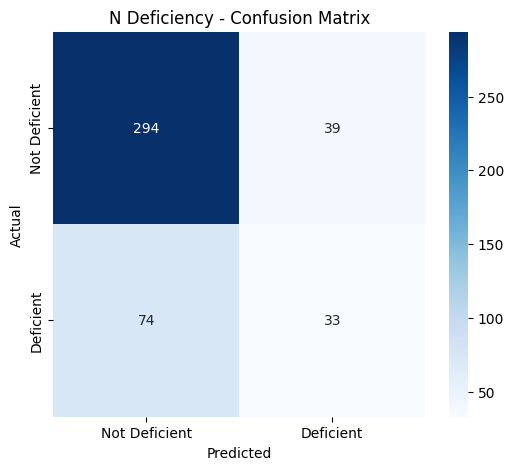

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_N = confusion_matrix(y_N_test, y_N_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_N,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Deficient", "Deficient"],
    yticklabels=["Not Deficient", "Deficient"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("N Deficiency - Confusion Matrix")
plt.show()

In [ ]:
feature_importance_N = pd.Series(
    gb_N.feature_importances_,
    index=X_N_train.columns
).sort_values(ascending=False)

print("Top features for N deficiency prediction:")
display(feature_importance_N.head(10))

Top features for N deficiency prediction:


,0
humidity,0.207800
rainfall,0.136416
P,0.135660
K,0.135634
temperature,0.069383
ph,0.050351
frost_risk,0.031456
urban_area_proximity,0.030441
sunlight_exposure,0.028117
co2_concentration,0.025085


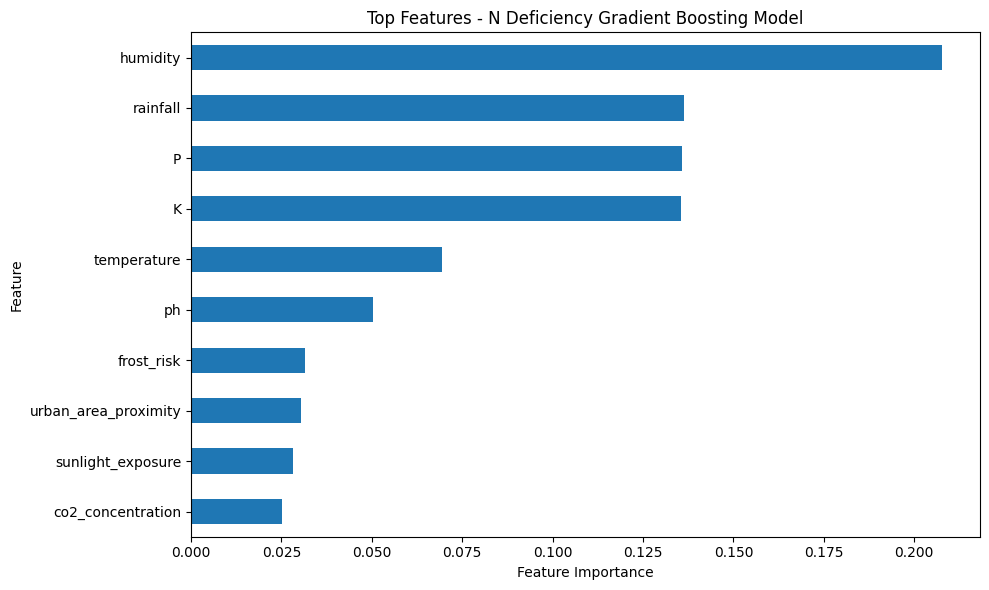

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance_N.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features - N Deficiency Gradient Boosting Model")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_P = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_P.fit(X_P_train, y_P_train)

print("P deficiency model trained successfully.")

P deficiency model trained successfully.


In [ ]:
y_P_pred = gb_P.predict(X_P_test)

print("First 20 predictions:")
print(y_P_pred[:20])

print("\nFirst 20 actual values:")
print(y_P_test.values[:20])

First 20 predictions:
[1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0]

First 20 actual values:
[1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0]


In [ ]:
accuracy_P = accuracy_score(y_P_test, y_P_pred)
precision_P = precision_score(y_P_test, y_P_pred)
recall_P = recall_score(y_P_test, y_P_pred)
f1_P = f1_score(y_P_test, y_P_pred)

print("P Deficiency Model Performance")
print(f"Accuracy : {accuracy_P:.4f}")
print(f"Precision: {precision_P:.4f}")
print(f"Recall   : {recall_P:.4f}")
print(f"F1 Score : {f1_P:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_P_test,
        y_P_pred,
        target_names=["Not Deficient", "Deficient"]
    )
)

P Deficiency Model Performance
Accuracy : 0.9273
Precision: 0.8333
Recall   : 0.8796
F1 Score : 0.8559

Classification Report:
               precision    recall  f1-score   support

Not Deficient       0.96      0.94      0.95       332
    Deficient       0.83      0.88      0.86       108

     accuracy                           0.93       440
    macro avg       0.90      0.91      0.90       440
 weighted avg       0.93      0.93      0.93       440



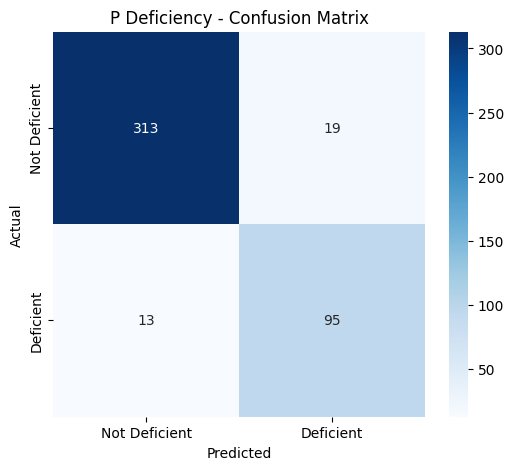

In [ ]:
cm_P = confusion_matrix(y_P_test, y_P_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_P,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Deficient", "Deficient"],
    yticklabels=["Not Deficient", "Deficient"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("P Deficiency - Confusion Matrix")
plt.show()

In [ ]:
gb_K = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_K.fit(X_K_train, y_K_train)

print("K deficiency model trained successfully.")

K deficiency model trained successfully.


In [ ]:
y_K_pred = gb_K.predict(X_K_test)

print("First 20 predictions:")
print(y_K_pred[:20])

print("\nFirst 20 actual values:")
print(y_K_test.values[:20])

First 20 predictions:
[0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0]

First 20 actual values:
[0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0]


In [ ]:
accuracy_K = accuracy_score(y_K_test, y_K_pred)
precision_K = precision_score(y_K_test, y_K_pred)
recall_K = recall_score(y_K_test, y_K_pred)
f1_K = f1_score(y_K_test, y_K_pred)

print("K Deficiency Model Performance")
print(f"Accuracy : {accuracy_K:.4f}")
print(f"Precision: {precision_K:.4f}")
print(f"Recall   : {recall_K:.4f}")
print(f"F1 Score : {f1_K:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_K_test,
        y_K_pred,
        target_names=["Not Deficient", "Deficient"]
    )
)

K Deficiency Model Performance
Accuracy : 0.8205
Precision: 0.6545
Recall   : 0.3750
F1 Score : 0.4768

Classification Report:
               precision    recall  f1-score   support

Not Deficient       0.84      0.94      0.89       344
    Deficient       0.65      0.38      0.48        96

     accuracy                           0.82       440
    macro avg       0.75      0.66      0.68       440
 weighted avg       0.80      0.82      0.80       440



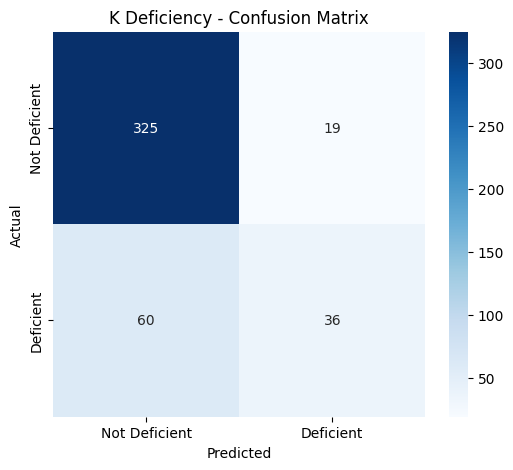

In [ ]:
cm_K = confusion_matrix(y_K_test, y_K_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_K,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Deficient", "Deficient"],
    yticklabels=["Not Deficient", "Deficient"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("K Deficiency - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid_N = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10]
}

grid_N = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_N,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_N.fit(X_N_train, y_N_train)

print("Best parameters:")
print(grid_N.best_params_)

print("\nBest cross-validation F1:")
print(grid_N.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validation F1:
0.43294863958907837


In [ ]:
best_N = grid_N.best_estimator_

y_N_tuned_pred = best_N.predict(X_N_test)

accuracy_N_tuned = accuracy_score(y_N_test, y_N_tuned_pred)
precision_N_tuned = precision_score(y_N_test, y_N_tuned_pred)
recall_N_tuned = recall_score(y_N_test, y_N_tuned_pred)
f1_N_tuned = f1_score(y_N_test, y_N_tuned_pred)

print("Tuned N Deficiency Model")
print(f"Accuracy : {accuracy_N_tuned:.4f}")
print(f"Precision: {precision_N_tuned:.4f}")
print(f"Recall   : {recall_N_tuned:.4f}")
print(f"F1 Score : {f1_N_tuned:.4f}")

Tuned N Deficiency Model
Accuracy : 0.7500
Precision: 0.4815
Recall   : 0.3645
F1 Score : 0.4149


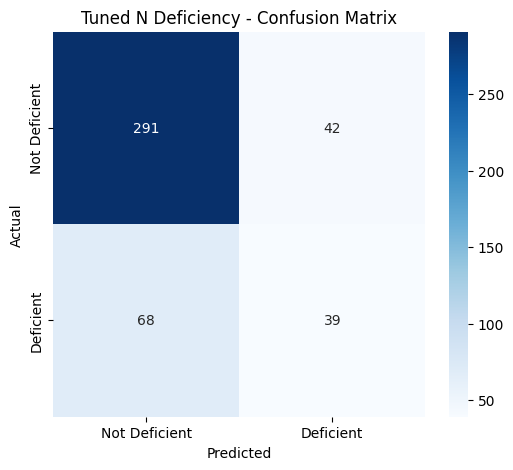

In [ ]:
cm_N_tuned = confusion_matrix(y_N_test, y_N_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_N_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Deficient", "Deficient"],
    yticklabels=["Not Deficient", "Deficient"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned N Deficiency - Confusion Matrix")
plt.show()

In [ ]:
def tune_gradient_boosting(X_train, y_train, X_test, y_test, nutrient_name):

    param_grid = {
        "n_estimators": [100, 150, 200],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "min_samples_split": [2, 5, 10]
    }

    grid = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=42),
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    predictions = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n{'='*50}")
    print(f"{nutrient_name} Deficiency - Tuned Model")
    print(f"{'='*50}")

    print("\nBest parameters:")
    print(grid.best_params_)

    print(f"\nBest CV F1: {grid.best_score_:.4f}")

    print("\nTest Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Not Deficient", "Deficient"]
        )
    )

    return best_model, predictions, grid.best_params_, grid.best_score_

In [ ]:
best_P, y_P_tuned_pred, best_P_params, best_P_cv_f1 = tune_gradient_boosting(
    X_P_train,
    y_P_train,
    X_P_test,
    y_P_test,
    "P"
)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

P Deficiency - Tuned Model

Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}

Best CV F1: 0.8697

Test Performance:
Accuracy : 0.9250
Precision: 0.8261
Recall   : 0.8796
F1 Score : 0.8520

Classification Report:
               precision    recall  f1-score   support

Not Deficient       0.96      0.94      0.95       332
    Deficient       0.83      0.88      0.85       108

     accuracy                           0.93       440
    macro avg       0.89      0.91      0.90       440
 weighted avg       0.93      0.93      0.93       440



In [ ]:
best_K, y_K_tuned_pred, best_K_params, best_K_cv_f1 = tune_gradient_boosting(
    X_K_train,
    y_K_train,
    X_K_test,
    y_K_test,
    "K"
)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

K Deficiency - Tuned Model

Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 150}

Best CV F1: 0.4274

Test Performance:
Accuracy : 0.8091
Precision: 0.5857
Recall   : 0.4271
F1 Score : 0.4940

Classification Report:
               precision    recall  f1-score   support

Not Deficient       0.85      0.92      0.88       344
    Deficient       0.59      0.43      0.49        96

     accuracy                           0.81       440
    macro avg       0.72      0.67      0.69       440
 weighted avg       0.79      0.81      0.80       440



In [ ]:
accuracy_K_tuned = accuracy_score(y_K_test, y_K_tuned_pred)
precision_K_tuned = precision_score(y_K_test, y_K_tuned_pred)
recall_K_tuned = recall_score(y_K_test, y_K_tuned_pred)
f1_K_tuned = f1_score(y_K_test, y_K_tuned_pred)

print("K tuned metrics calculated successfully.")
print(f"Accuracy : {accuracy_K_tuned:.4f}")
print(f"Precision: {precision_K_tuned:.4f}")
print(f"Recall   : {recall_K_tuned:.4f}")
print(f"F1 Score : {f1_K_tuned:.4f}")

K tuned metrics calculated successfully.
Accuracy : 0.8091
Precision: 0.5857
Recall   : 0.4271
F1 Score : 0.4940


In [ ]:
final_results = pd.DataFrame({
    "Nutrient": ["N", "P", "K"],
    "Model": [
        "Tuned Gradient Boosting",
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_N_tuned,
        accuracy_P,
        accuracy_K_tuned
    ],
    "Precision": [
        precision_N_tuned,
        precision_P,
        precision_K_tuned
    ],
    "Recall": [
        recall_N_tuned,
        recall_P,
        recall_K_tuned
    ],
    "F1 Score": [
        f1_N_tuned,
        f1_P,
        f1_K_tuned
    ]
})

final_results["Accuracy"] = final_results["Accuracy"].round(4)
final_results["Precision"] = final_results["Precision"].round(4)
final_results["Recall"] = final_results["Recall"].round(4)
final_results["F1 Score"] = final_results["F1 Score"].round(4)

display(final_results)

,Nutrient,Model,Accuracy,Precision,Recall,F1 Score
0,N,Tuned Gradient Boosting,0.7500,0.4815,0.3645,0.4149
1,P,Baseline Gradient Boosting,0.9273,0.8333,0.8796,0.8559
2,K,Tuned Gradient Boosting,0.8091,0.5857,0.4271,0.4940


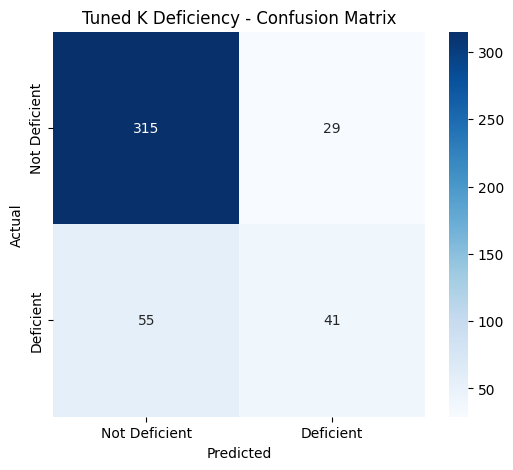

In [ ]:
cm_K_tuned = confusion_matrix(y_K_test, y_K_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_K_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Deficient", "Deficient"],
    yticklabels=["Not Deficient", "Deficient"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned K Deficiency - Confusion Matrix")
plt.show()

In [ ]:
import os
import joblib

MODEL_DIR = "/content/drive/MyDrive/Soil_Analytics_Project/Models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:


joblib.dump(
    best_N,
    os.path.join(MODEL_DIR, "N_deficiency_gradient_boosting.pkl")
)

joblib.dump(
    gb_P,
    os.path.join(MODEL_DIR, "P_deficiency_gradient_boosting.pkl")
)

joblib.dump(
    best_K,
    os.path.join(MODEL_DIR, "K_deficiency_gradient_boosting.pkl")
)

print("Final structured ML models saved successfully.")

Final structured ML models saved successfully.


In [ ]:
print("Saved model files:")

for filename in [
    "N_deficiency_gradient_boosting.pkl",
    "P_deficiency_gradient_boosting.pkl",
    "K_deficiency_gradient_boosting.pkl"
]:
    path = os.path.join(MODEL_DIR, filename)
    print(filename, "→", os.path.exists(path))

Saved model files:
N_deficiency_gradient_boosting.pkl → True
P_deficiency_gradient_boosting.pkl → True
K_deficiency_gradient_boosting.pkl → True


## Final Model Selection

The tuned model is not automatically selected for every nutrient. Baseline
and tuned models are compared using the held-out test-set metrics.

Final selections:

- N: tuned Gradient Boosting model
- P: baseline Gradient Boosting model
- K: tuned Gradient Boosting model

For P, the baseline model achieved a slightly higher test F1-score than the
tuned model, so the baseline model was retained.

For K, tuning improved recall and F1-score, so the tuned model was retained
despite a reduction in accuracy.

This selection prioritizes the model behavior relevant to deficiency
detection rather than selecting a model solely because it underwent tuning.

# Structured ML — Final Summary

## Dataset

- 2,200 observations
- 22 input features
- Original target: crop recommendation
- N/P/K deficiency targets: dataset-relative proxy labels

## Modeling

Three binary Gradient Boosting classifiers were developed:

- N deficiency
- P deficiency
- K deficiency

The nutrient used to construct each target was excluded from that nutrient's
feature matrix to prevent direct target leakage.

An 80/20 stratified train-test split was used, followed by baseline modeling
and 5-fold cross-validated hyperparameter tuning.

## Final Models

| Nutrient | Selected Model | Accuracy | Precision | Recall | F1 |
|---|---|---:|---:|---:|---:|
| N | Tuned Gradient Boosting | 0.7500 | 0.4815 | 0.3645 | 0.4149 |
| P | Baseline Gradient Boosting | 0.9273 | 0.8333 | 0.8796 | 0.8559 |
| K | Tuned Gradient Boosting | 0.8091 | 0.5857 | 0.4271 | 0.4940 |

The final models are saved in the project's `Models` directory and are used
by the SHAP and hybrid-analysis notebooks.

## Important Limitation

The deficiency targets are proxy labels derived from the distributions of
the provided dataset. They should not be interpreted as laboratory-confirmed
nutrient deficiency measurements or as universal agronomic thresholds.